## **Training a Learner on an Environment**

In [ ]:
#@title Installation

# For first time setup:

!git clone https://github.com/google/deluca 
%cd deluca

!git checkout improved-api


!pip install -e .

In [1]:
#@title Imports and Helper Functions for Plotting

%load_ext autoreload
%autoreload 1

from deluca.agents.new.linear import LinearAgent, DefaultSettings as DefaultLinearAgentSettings
from deluca.envs._brax import BraxEnv
from deluca.agents._grc import GRC
from deluca.agents.new.random import SimpleRandom
from deluca.agents._zero import Zero
from deluca.envs.brax._pendulum2d import Pendulum2D
from deluca.filters.spectral import SpectralFilter
from deluca.learners.feedforward import (
    FFLearner,
    FFLearnerSettings,
    DefaultSettings as FFLearnerDefaultSettings,
)
from deluca.learners.core import Learner
from deluca.learners.linear import (
    LinearLearner,
    LinearLearnerSettings,
    DefaultSettings as LinearDefaultSettings,
)
from deluca.memory import Memory, MemorySettings
from deluca.envs._lds import LDS, SinusDisturbance, ZeroDisturbance
import jax
import jax.numpy as jnp
import numpy as np

import flax.nnx as nnx

import matplotlib
import matplotlib.pyplot as plt

from deluca.memory.utils import generate_histories
from deluca.utils.printing import progress


def pred_vs_true_plot(learner: Learner, history_length: int, histories, ax, rng):
    """
    Plot the predicted vs true next observations as a scatter plot on the given axis.
    """
    obs, actions, next_obs = histories

    # Get predictions from the learner
    pred = learner.predict(obs, actions, rng)

    pred = jnp.squeeze(pred, -1)

    assert (
        pred.shape[-1] == next_obs.shape[-1]
    ), "Predictions and next observations must have the same number of dimensions"

    true = next_obs.reshape(-1, next_obs.shape[-1])
    pred = pred.reshape(-1, pred.shape[-1])

    hfi = history_length
    colors = [
        "red",
        "blue",
        "green",
        "orange",
        "purple",
        "brown",
        "pink",
        "gray",
        "olive",
        "cyan",
        "lime",
        "teal",
        "indigo",
        "violet",
        "coral",
        "maroon",
        "navy",
        "gold",
        "silver",
        "black",
        "white",
        "coral",
        "maroon",
        "navy",
    ]
    alphas = np.linspace(0.1, 0.85, true.shape[0] - hfi).tolist()

    for i in range(true.shape[-1]):
        ax.scatter(
            true[:hfi, i],
            pred[:hfi, i],
            alpha=0.8,
            label=None,
            s=25,
            color=colors[i],
            marker="x",
        )
        ax.scatter(
            true[hfi:, i],
            pred[hfi:, i],
            alpha=alphas,
            label=f"y_{i}",
            s=20,
            color=colors[i],
            marker="o",
        )

    # Add diagonal line for perfect predictions
    min_val = min(ax.get_xlim()[0], ax.get_ylim()[0])
    max_val = max(ax.get_xlim()[1], ax.get_ylim()[1])
    ax.plot(
        [min_val, max_val],
        [min_val, max_val],
        "k--",
        alpha=0.5,
        label="Perfect prediction",
    )

    ax.set_xlabel("True next observations")
    ax.set_ylabel("Predicted next observations")
    ax.set_title(f"Predicted vs True: {learner.name}")
    ax.legend(bbox_to_anchor=(1.05, 1), loc="upper left")
    ax.grid(True, alpha=0.3)

def plot_losses(learner: Learner, train_losses, test_losses, batches_per_test, ax):
    """Plot losses on the given axis."""

    train_losses = train_losses.reshape(-1)
    test_losses = test_losses.reshape(-1)

    ax.plot(train_losses, label="Train")
    ax.plot(np.arange(0, len(test_losses)) * batches_per_test, test_losses, label="Test")
    ax.set_xlabel("Batch")
    ax.set_ylabel("Loss")
    ax.set_title(f"Losses for {learner.name}")
    ax.legend()
    ax.grid(True, alpha=0.3)


In [2]:
%autoreload 1
#@title Choosing an Environment to Learn

import jax

from deluca.envs._brax import BraxEnv

# Create a random key with a seed
rng = jax.random.key(0)

# Creating the environment
rng, env_rng = jax.random.split(rng)
env = BraxEnv(env_rng, "reacher")

/Users/rsalik/.pyenv/versions/3.13.1/envs/deluca-env/lib/python3.13/site-packages/brax/io/mjcf.py:480: UserWarning: Brax System, piplines and environments are not actively being maintained. Please see MJX for a well maintained JAX-based physics engine: https://github.com/google-deepmind/mujoco/tree/main/mjx. For a host of environments that use MJX, see: https://github.com/google-deepmind/mujoco_playground.
  warnings.warn(


### **Picking MemorySettings**

MemorySettings controls how much history the learner uses to make predictions.
Setting `history_length` to 1 means the learner only sees the obs_t when predicting obs_t+1, for example.

MemorySettings also takes a `filter`, which we can use to apply Spectral Filtering to the history—in this case, our Learner will see the post-spectral-filtering history before making a prediction.

In [3]:
%autoreload 1

filter = SpectralFilter(env.observation_size, env.action_size)
memory_settings = MemorySettings.from_env(env, 20, filter)

In [ ]:
#@title Creating our Learner
%autoreload 1
from deluca.normalizers.core import DefaultNormalizers


settings = FFLearnerDefaultSettings

# Normalization of observations and actions, if we want
# We can also manipulate input and output, eg. ignore the 2nd dimension of the observation by setting it to 0 always.
#normalizers = DefaultNormalizers() 
# Not sure normalization works right now,


rng, learner_key = jax.random.split(rng)
ff_learner = FFLearner(memory_settings, settings, rng, normalizers=None)

settings = LinearDefaultSettings
linear_learner = LinearLearner(memory_settings, settings, rng, normalizers=None)

### **Training our Learner**

Generate pre-constructed histories that we will use to train our learner
- We will need an agent to perform actions in the environment--the Learner will be good at predicting future states in our environment, when that agent is controlling. It may not generalize to other agents.

In [5]:
#@title Generate histories
 

N = 500 # Number of trajectories to generate
T = 50 # Length of each trajectory
TEST_AMT = 50 # Number of trajectories to hold out for testing

rng, agent_rng = jax.random.split(rng)
agent = LinearAgent(memory_settings, DefaultLinearAgentSettings, rng=agent_rng) # the agent can have any memory settings, not necessarily the same as the learner

rng, h1_rng, h2_rng = jax.random.split(rng, 3)
train_histories = generate_histories(env, agent, memory_settings, N - TEST_AMT, T, rng=h1_rng)
test_histories = generate_histories(env, agent, memory_settings, TEST_AMT, T, rng=h2_rng)

In [6]:
#@title Training our Learner
%autoreload 1

ff_train_losses, ff_test_losses = ff_learner.train(train_histories, learner_key)
linear_train_losses, linear_test_losses = linear_learner.train(train_histories, learner_key)

ValueError: Incompatible shapes for broadcasting: shapes=[(13950, 11), (264,)]

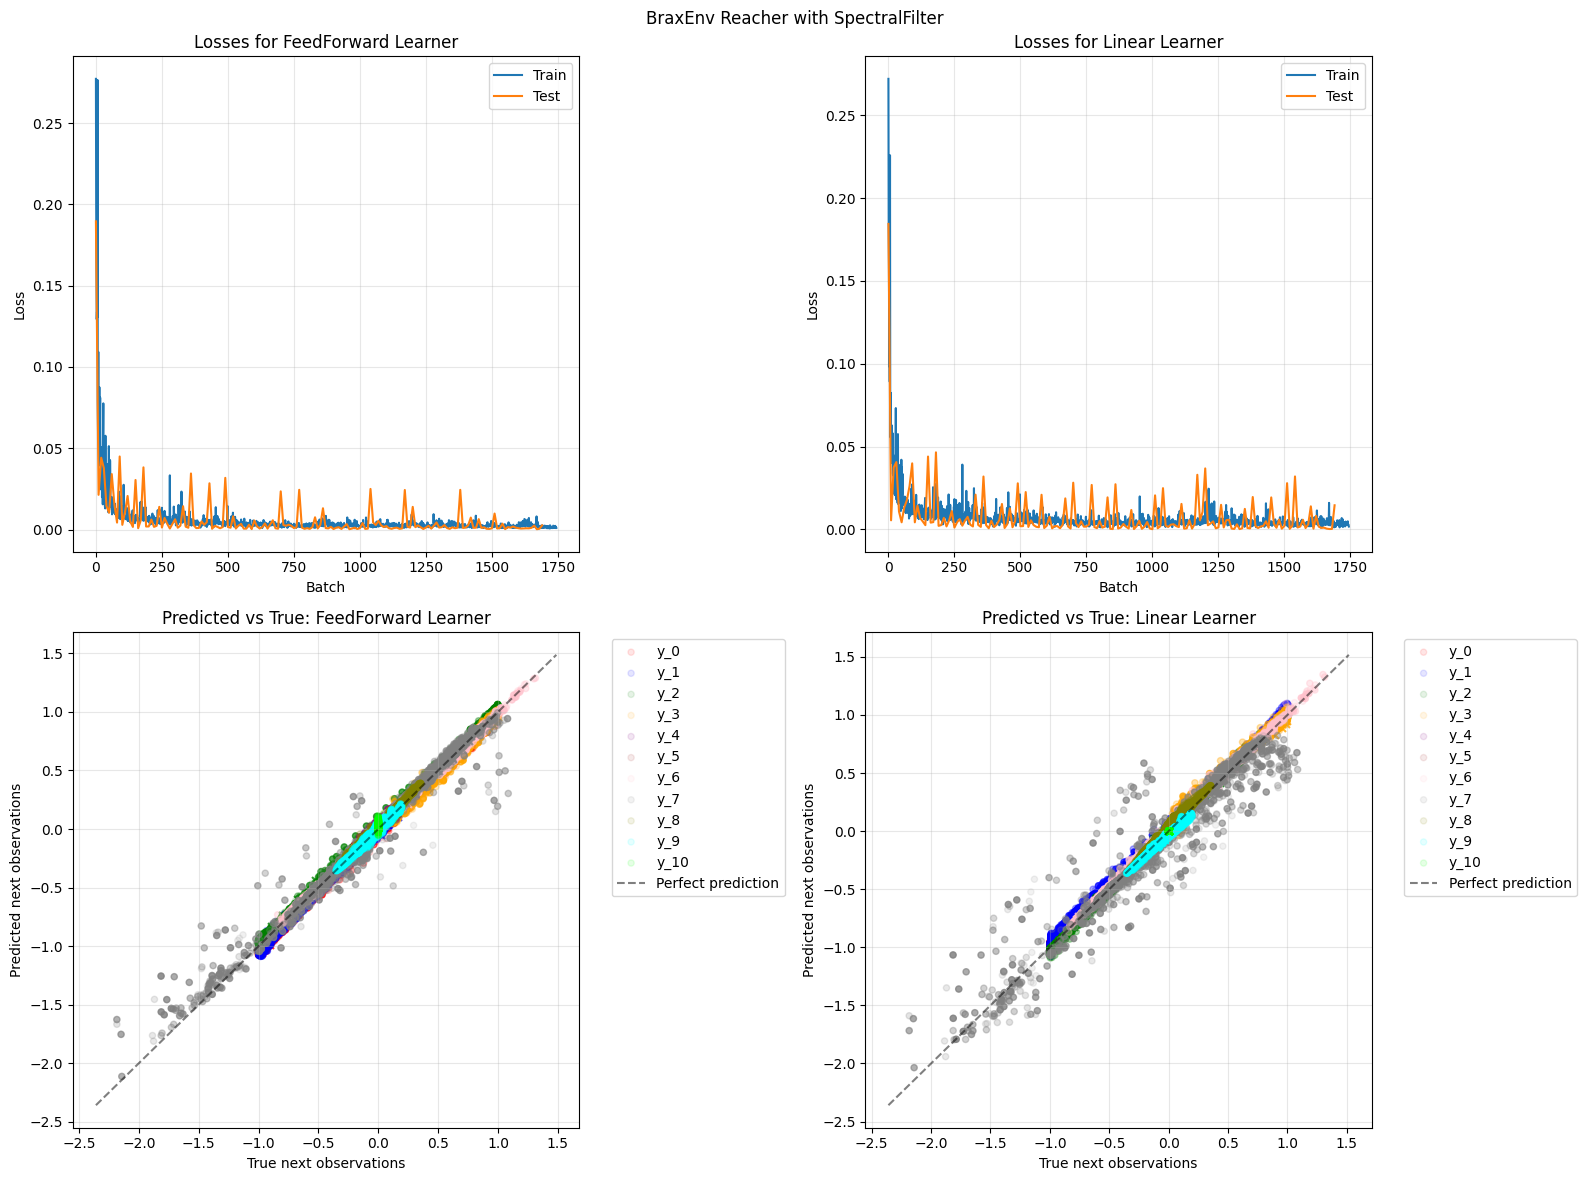

In [ ]:
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

plot_losses(ff_learner, ff_train_losses, ff_test_losses, settings.batches_per_test, axes[0, 0])
plot_losses(linear_learner, linear_train_losses, linear_test_losses, settings.batches_per_test, axes[0, 1])

pred_vs_true_plot(ff_learner, memory_settings.history_length, test_histories, axes[1, 0], rng)
pred_vs_true_plot(linear_learner, memory_settings.history_length, test_histories, axes[1, 1], rng)

plt.tight_layout()
plt.show()
